# Figure 2 — EDA multipanel for manuscript

This notebook generates a clean, manuscript-ready multipanel figure summarizing the exploratory analysis of the early-pregnancy clinical feature space. The layout is designed for a Nature-style paper figure with simplified labels, colorblind-friendly colors, and corrected correlation-matrix axis labels.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


## 1. Configuration

Adjust only this section if paths, file names, or figure settings change.

In [2]:
# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path("../../").resolve()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_variants"
EDA_ROOT = PROJECT_ROOT / "results" / "eda"
STATS_DIR = EDA_ROOT / "stats"
FIG_DIR = EDA_ROOT / "figures" / "paper_panel"

STRICT_CSV = DATA_PROCESSED_DIR / "hcs_strict_complete_case_20260129_114259.csv"
IMPUTED_CSV = DATA_PROCESSED_DIR / "hcs_imputed_exploratory_20260129_114259.csv"

FIG_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Analysis settings
# ---------------------------------------------------------------------
LABEL_COL = "MSPH"
DATASET_FOR_FIGURE = "strict"  # options: "strict", "imputed"

N_DISTRIBUTION_FEATURES = 4
USE_MANUAL_DISTRIBUTION_FEATURES = True
MANUAL_DISTRIBUTION_FEATURES = [
    "TC_1T",
    "LDL_1T",
    "TG_1T",
    "HDL_1T",
]

CORR_METHOD = "pearson"  # options: "pearson", "spearman"
FEATURE_SET_FOR_CORR = "full"  # options: "full", "pruned"
FEATURE_SET_FOR_PROJECTION = "pruned"  # options: "full", "pruned"
RANDOM_STATE = 42

# ---------------------------------------------------------------------
# Figure export settings
# ---------------------------------------------------------------------
FIGURE_BASENAME = "figure2_eda_panel_nature_style"
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True
ADD_SUPTITLE = False  # manuscript figures usually rely on the caption, not an internal title

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STRICT_CSV:", STRICT_CSV)
print("IMPUTED_CSV:", IMPUTED_CSV)
print("FIG_DIR:", FIG_DIR)


PROJECT_ROOT: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers
STRICT_CSV: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/data/processed_variants/hcs_strict_complete_case_20260129_114259.csv
IMPUTED_CSV: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/data/processed_variants/hcs_imputed_exploratory_20260129_114259.csv
FIG_DIR: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/eda/figures/paper_panel


## 2. Utility functions

In [3]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Load a CSV dataset and raise a clear error if the file is missing."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")
    return pd.read_csv(path)


def load_feature_list(path: Path) -> Optional[List[str]]:
    """Load a feature list from a CSV file containing a `feature` column."""
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if "feature" not in df.columns:
        return None
    return df["feature"].dropna().astype(str).tolist()


def resolve_numeric_features(df: pd.DataFrame, label_col: str, meta_cols: Optional[Sequence[str]] = None) -> List[str]:
    """Infer numeric predictors by excluding label and metadata columns."""
    meta_cols = list(meta_cols or [])
    blacklist = set(meta_cols + [label_col])
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in numeric_cols if c not in blacklist]


def intersect_existing(features: Sequence[str], df: pd.DataFrame) -> List[str]:
    """Return only features that exist in a dataframe, preserving order."""
    return [f for f in features if f in df.columns]


def choose_dataset(name: str, df_strict: pd.DataFrame, df_imputed: pd.DataFrame) -> pd.DataFrame:
    """Return the requested dataset variant."""
    name = name.lower().strip()
    if name == "strict":
        return df_strict.copy()
    if name == "imputed":
        return df_imputed.copy()
    raise ValueError("DATASET_FOR_FIGURE must be either 'strict' or 'imputed'.")


## 3. Statistical helpers for feature ranking

These functions allow automatic selection of the most discriminative features for the distribution panels.

In [4]:
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """Compute Cliff's delta for two independent samples."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    greater = sum((xi > y).sum() for xi in x)
    lower = sum((xi < y).sum() for xi in x)
    return (greater - lower) / (len(x) * len(y))


def benjamini_hochberg(p_values: Sequence[float]) -> np.ndarray:
    """Benjamini-Hochberg FDR correction."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty_like(q)
    out[order] = q
    return out


def run_group_comparisons(df: pd.DataFrame, label_col: str, features: Sequence[str]) -> pd.DataFrame:
    """Run Mann-Whitney U tests and Cliff's delta for binary outcome groups."""
    y = df[label_col].dropna().unique()
    if len(y) != 2:
        raise ValueError(f"Expected binary label column, found {len(y)} classes.")
    classes = sorted(y)
    negative_label, positive_label = classes[0], classes[1]
    rows = []
    for feature in features:
        if feature not in df.columns:
            continue
        values = pd.to_numeric(df[feature], errors="coerce")
        group_neg = values[df[label_col] == negative_label].dropna().to_numpy()
        group_pos = values[df[label_col] == positive_label].dropna().to_numpy()
        if len(group_neg) < 2 or len(group_pos) < 2:
            continue
        try:
            _, p_value = stats.mannwhitneyu(group_pos, group_neg, alternative="two-sided")
        except Exception:
            p_value = np.nan
        effect = cliffs_delta(group_pos, group_neg)
        rows.append({
            "feature": feature,
            "n_negative": len(group_neg),
            "n_positive": len(group_pos),
            "median_negative": np.nanmedian(group_neg),
            "median_positive": np.nanmedian(group_pos),
            "median_difference_pos_minus_neg": np.nanmedian(group_pos) - np.nanmedian(group_neg),
            "cliffs_delta_pos_vs_neg": effect,
            "abs_cliffs_delta": abs(effect),
            "p_value": p_value,
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["q_value_fdr"] = benjamini_hochberg(out["p_value"].fillna(1.0).to_numpy())
        out = out.sort_values(["q_value_fdr", "abs_cliffs_delta"], ascending=[True, False]).reset_index(drop=True)
    return out


## 4. Load datasets and feature sets

In [5]:
df_strict = load_dataset(STRICT_CSV)
df_imputed = load_dataset(IMPUTED_CSV)
df_fig = choose_dataset(DATASET_FOR_FIGURE, df_strict, df_imputed)

print("STRICT:", df_strict.shape)
print("IMPUTED:", df_imputed.shape)
print("FIGURE DATASET:", DATASET_FOR_FIGURE, df_fig.shape)
print("Label distribution:")
display(df_fig[LABEL_COL].value_counts(dropna=False).rename("count").to_frame())

META_COLS = ["row_id", "_sheet", "LocalID"]

full_features = (
    load_feature_list(STATS_DIR / "feature_set_full_used_in_nb04.csv")
    or load_feature_list(STATS_DIR / "feature_set_v1.csv")
    or resolve_numeric_features(df_fig, LABEL_COL, meta_cols=META_COLS)
)

pruned_features = (
    load_feature_list(STATS_DIR / "feature_set_pruned_union_thr0.80_used_in_nb04.csv")
    or full_features
)

full_features = intersect_existing(full_features, df_fig)
pruned_features = intersect_existing(pruned_features, df_fig)

print(f"Full feature set: {len(full_features)} features")
print(f"Pruned feature set: {len(pruned_features)} features")
print("Full features:", full_features)
print("Pruned features:", pruned_features)


STRICT: (148, 15)
IMPUTED: (160, 15)
FIGURE DATASET: strict (148, 15)
Label distribution:


,count
MSPH,
0,106
1,42


Full feature set: 11 features
Pruned feature set: 9 features
Full features: ['Age', 'BMI_final', 'DBP_1T', 'Glycemia', 'HDL_1T', 'Height', 'LDL_1T', 'SBP_1T', 'TC_1T', 'TG_1T', 'Weight']
Pruned features: ['Age', 'DBP_1T', 'Glycemia', 'HDL_1T', 'Height', 'SBP_1T', 'TC_1T', 'TG_1T', 'Weight']


## 5. Select features for top-row distribution panels

By default, the notebook uses manually defined lipid-related predictors if present. If any are missing, it falls back to an automatic ranking based on group-wise effect size and FDR-adjusted statistical evidence.

In [6]:
group_stats = run_group_comparisons(df_fig, LABEL_COL, full_features)

group_stats_path = STATS_DIR / f"figure1_group_stats_{DATASET_FOR_FIGURE}.csv"
group_stats.to_csv(group_stats_path, index=False)
print("Saved group statistics:", group_stats_path)

display(group_stats.head(20))

manual_candidates = intersect_existing(MANUAL_DISTRIBUTION_FEATURES, df_fig)

if USE_MANUAL_DISTRIBUTION_FEATURES and len(manual_candidates) >= N_DISTRIBUTION_FEATURES:
    distribution_features = manual_candidates[:N_DISTRIBUTION_FEATURES]
else:
    distribution_features = group_stats["feature"].head(N_DISTRIBUTION_FEATURES).tolist()

print("Distribution features:", distribution_features)


Saved group statistics: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/eda/stats/figure1_group_stats_strict.csv


,feature,n_negative,n_positive,median_negative,median_positive,median_difference_pos_minus_neg,cliffs_delta_pos_vs_neg,abs_cliffs_delta,p_value,q_value_fdr
0,TC_1T,106,42,172.50,199.00,26.50,0.560422,0.560422,1.125618e-07,0.000001
1,LDL_1T,106,42,96.90,125.30,28.40,0.515049,0.515049,1.091656e-06,0.000006
2,SBP_1T,106,42,106.00,110.00,4.00,0.229111,0.229111,2.935766e-02,0.091049
3,HDL_1T,106,42,55.85,60.35,4.50,0.224169,0.224169,3.396545e-02,0.091049
4,Age,106,42,29.50,31.00,1.50,0.215184,0.215184,4.138574e-02,0.091049
5,BMI_final,106,42,24.35,22.70,-1.65,-0.189353,0.189353,7.330707e-02,0.134396
6,Weight,106,42,61.50,60.00,-1.50,-0.141959,0.141959,1.791179e-01,0.281471
7,Height,106,42,161.00,163.00,2.00,0.079739,0.079739,4.509634e-01,0.620075
8,DBP_1T,106,42,64.00,64.50,0.50,0.057278,0.057278,5.861599e-01,0.660896
9,Glycemia,106,42,78.25,78.20,-0.05,-0.055481,0.055481,6.008149e-01,0.660896


Distribution features: ['TC_1T', 'LDL_1T', 'TG_1T', 'HDL_1T']


## 6. Plotting helpers

In [7]:
# ---------------------------------------------------------------------
# Display labels and style constants
# ---------------------------------------------------------------------
from matplotlib.lines import Line2D

FEATURE_LABELS: Dict[str, str] = {
    "TC_1T": "Total cholesterol 1T",
    "LDL_1T": "LDL cholesterol 1T",
    "TG_1T": "Triglycerides 1T",
    "HDL_1T": "HDL cholesterol 1T",
    "SBP_1T": "Systolic BP 1T",
    "DBP_1T": "Diastolic BP 1T",
    "BMI_final": "BMI",
    "Weight": "Weight",
    "Height": "Height",
    "Glycemia_1T": "Glycemia 1T",
    "Age": "Age",
}

# Short labels are used in the correlation matrix to prevent x-axis overlap.
FEATURE_LABELS_SHORT: Dict[str, str] = {
    "TC_1T": "TC 1T",
    "LDL_1T": "LDL-C 1T",
    "TG_1T": "TG 1T",
    "HDL_1T": "HDL-C 1T",
    "SBP_1T": "SBP 1T",
    "DBP_1T": "DBP 1T",
    "BMI_final": "BMI",
    "Weight": "Weight",
    "Height": "Height",
    "Glycemia_1T": "Glycemia",
    "Age": "Age",
}

CLASS_LABELS: Dict[int, str] = {0: "MSPH−", 1: "MSPH+"}
CLASS_ORDER = ["MSPH−", "MSPH+"]

# Palette harmonized with the methodology figure:
# deep clinical blue for MSPH− and warm orange for MSPH+.
CLASS_PALETTE = {
    "MSPH−": "#1F5A91",
    "MSPH+": "#D97721",
}

# Softer diverging palette for annotated correlation matrix.
CORR_CMAP = sns.diverging_palette(235, 20, s=85, l=55, center="light", as_cmap=True)


def pretty_feature_name(feature: str) -> str:
    """Return a clean display name for a feature."""
    return FEATURE_LABELS.get(feature, feature.replace("_", " "))


def pretty_feature_name_short(feature: str) -> str:
    """Return a compact label for dense axes such as correlation matrices."""
    return FEATURE_LABELS_SHORT.get(feature, pretty_feature_name(feature))


def add_panel_label(ax: plt.Axes, label: str) -> None:
    """Add a manuscript-style panel label to an axis."""
    ax.text(
        -0.16,
        1.12,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        ha="left",
    )


def remove_axis_legend(ax: plt.Axes) -> None:
    """Remove per-axis legends so the final figure can use one shared legend."""
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()


def plot_distribution(ax: plt.Axes, df: pd.DataFrame, feature: str, label_col: str) -> None:
    """Plot class-conditional distribution for one feature."""
    tmp = df[[feature, label_col]].copy()
    tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
    tmp = tmp.dropna(subset=[feature, label_col])
    tmp["class"] = tmp[label_col].map(CLASS_LABELS).fillna(tmp[label_col].astype(str))

    sns.histplot(
        data=tmp,
        x=feature,
        hue="class",
        hue_order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        bins="auto",
        stat="density",
        common_norm=False,
        kde=True,
        alpha=0.26,
        edgecolor="white",
        linewidth=0.55,
        ax=ax,
    )

    ax.set_title(pretty_feature_name(feature), fontsize=13, pad=9)
    ax.set_xlabel("")
    ax.set_ylabel("Density", fontsize=11)
    ax.grid(True, axis="y", alpha=0.22, linewidth=0.65)
    ax.grid(True, axis="x", alpha=0.08, linewidth=0.5)
    ax.tick_params(axis="both", labelsize=10)
    sns.despine(ax=ax)
    remove_axis_legend(ax)


def ordered_corr_matrix(corr: pd.DataFrame) -> pd.DataFrame:
    """Order a correlation matrix using hierarchical clustering."""
    if corr.shape[0] <= 2:
        return corr

    corr_clean = corr.fillna(0).clip(-1, 1)

    # Important: create a writable NumPy copy before modifying the diagonal.
    distance = (1 - np.abs(corr_clean)).to_numpy(copy=True)
    np.fill_diagonal(distance, 0)

    condensed = squareform(distance, checks=False)
    linkage = hierarchy.linkage(condensed, method="average")
    order = hierarchy.leaves_list(linkage)

    ordered_features = corr.index[order]
    return corr.loc[ordered_features, ordered_features]


def plot_correlation(ax: plt.Axes, df: pd.DataFrame, features: Sequence[str], method: str) -> None:
    """Plot a clustered and annotated correlation heatmap with readable labels."""
    X = df[list(features)].apply(pd.to_numeric, errors="coerce")
    corr = X.corr(method=method)
    corr = ordered_corr_matrix(corr)

    display_labels = [pretty_feature_name_short(c) for c in corr.columns]
    corr_display = corr.copy()
    corr_display.index = display_labels
    corr_display.columns = display_labels

    sns.heatmap(
        corr_display,
        vmin=-1,
        vmax=1,
        center=0,
        cmap=CORR_CMAP,
        square=False,
        linewidths=0.55,
        linecolor="white",
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 8.0, "color": "0.10"},
        cbar_kws={
            "shrink": 0.76,
            "pad": 0.025,
            "label": f"{method.title()} r",
            "ticks": [-1, -0.5, 0, 0.5, 1],
        },
        ax=ax,
    )

    ax.set_title("Correlation structure", fontsize=13, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=10,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.tick_params(axis="both", length=0, pad=3)

    # Improve colorbar readability
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(f"{method.title()} r", fontsize=11)


def build_projection_matrix(df: pd.DataFrame, features: Sequence[str], label_col: str) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Build scaled numeric matrix for PCA/t-SNE projections."""
    features = intersect_existing(features, df)
    X_raw = df[list(features)].apply(pd.to_numeric, errors="coerce")
    y = df[label_col].to_numpy()
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    X = pipe.fit_transform(X_raw)
    return X, y, list(features)


def plot_projection(ax: plt.Axes, Z: np.ndarray, y: np.ndarray, title: str, xlabel: str, ylabel: str) -> None:
    """Plot a 2D projection colored by class label."""
    tmp = pd.DataFrame({
        "x": Z[:, 0],
        "y": Z[:, 1],
        "class": pd.Series(y).map(CLASS_LABELS).fillna(pd.Series(y).astype(str)),
    })

    sns.scatterplot(
        data=tmp,
        x="x",
        y="y",
        hue="class",
        hue_order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        s=50,
        alpha=0.88,
        linewidth=0.35,
        edgecolor="white",
        ax=ax,
    )

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, alpha=0.18, linewidth=0.65)
    sns.despine(ax=ax)
    remove_axis_legend(ax)


def add_shared_class_legend(fig: plt.Figure) -> None:
    """Add one shared legend for all class-colored panels."""
    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=CLASS_PALETTE[label], markeredgecolor="white",
               markeredgewidth=0.6, label=label)
        for label in CLASS_ORDER
    ]
    legend = fig.legend(
        handles=handles,
        labels=CLASS_ORDER,
        title="Class",
        loc="center left",
        bbox_to_anchor=(0.905, 0.33),
        frameon=True,
        borderpad=0.8,
        labelspacing=0.7,
        handletextpad=0.6,
    )
    legend.get_title().set_fontsize(11)
    for text in legend.get_texts():
        text.set_fontsize(10.5)
    legend.get_frame().set_linewidth(0.7)
    legend.get_frame().set_edgecolor("0.70")
    legend.get_frame().set_alpha(0.95)

## 7. Generate the multipanel figure

In [8]:
corr_features = full_features if FEATURE_SET_FOR_CORR == "full" else pruned_features
projection_features = full_features if FEATURE_SET_FOR_PROJECTION == "full" else pruned_features

X_proj, y_proj, projection_features_used = build_projection_matrix(df_fig, projection_features, LABEL_COL)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca = pca.fit_transform(X_proj)

n_samples = X_proj.shape[0]
tsne_perplexity = max(5, min(30, (n_samples - 1) // 3))

tsne = TSNE(n_components=2, perplexity=tsne_perplexity, init="pca", learning_rate="auto", random_state=RANDOM_STATE)
Z_tsne = tsne.fit_transform(X_proj)

print("Projection features used:", projection_features_used)
print("PCA explained variance:", pca.explained_variance_ratio_)
print("t-SNE perplexity:", tsne_perplexity)


Projection features used: ['Age', 'DBP_1T', 'Glycemia', 'HDL_1T', 'Height', 'SBP_1T', 'TC_1T', 'TG_1T', 'Weight']
PCA explained variance: [0.22512961 0.19036013]
t-SNE perplexity: 30


Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/eda/figures/paper_panel/figure2_eda_panel_nature_style.png
Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/eda/figures/paper_panel/figure2_eda_panel_nature_style.pdf
Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/eda/figures/paper_panel/figure2_eda_panel_nature_style.svg


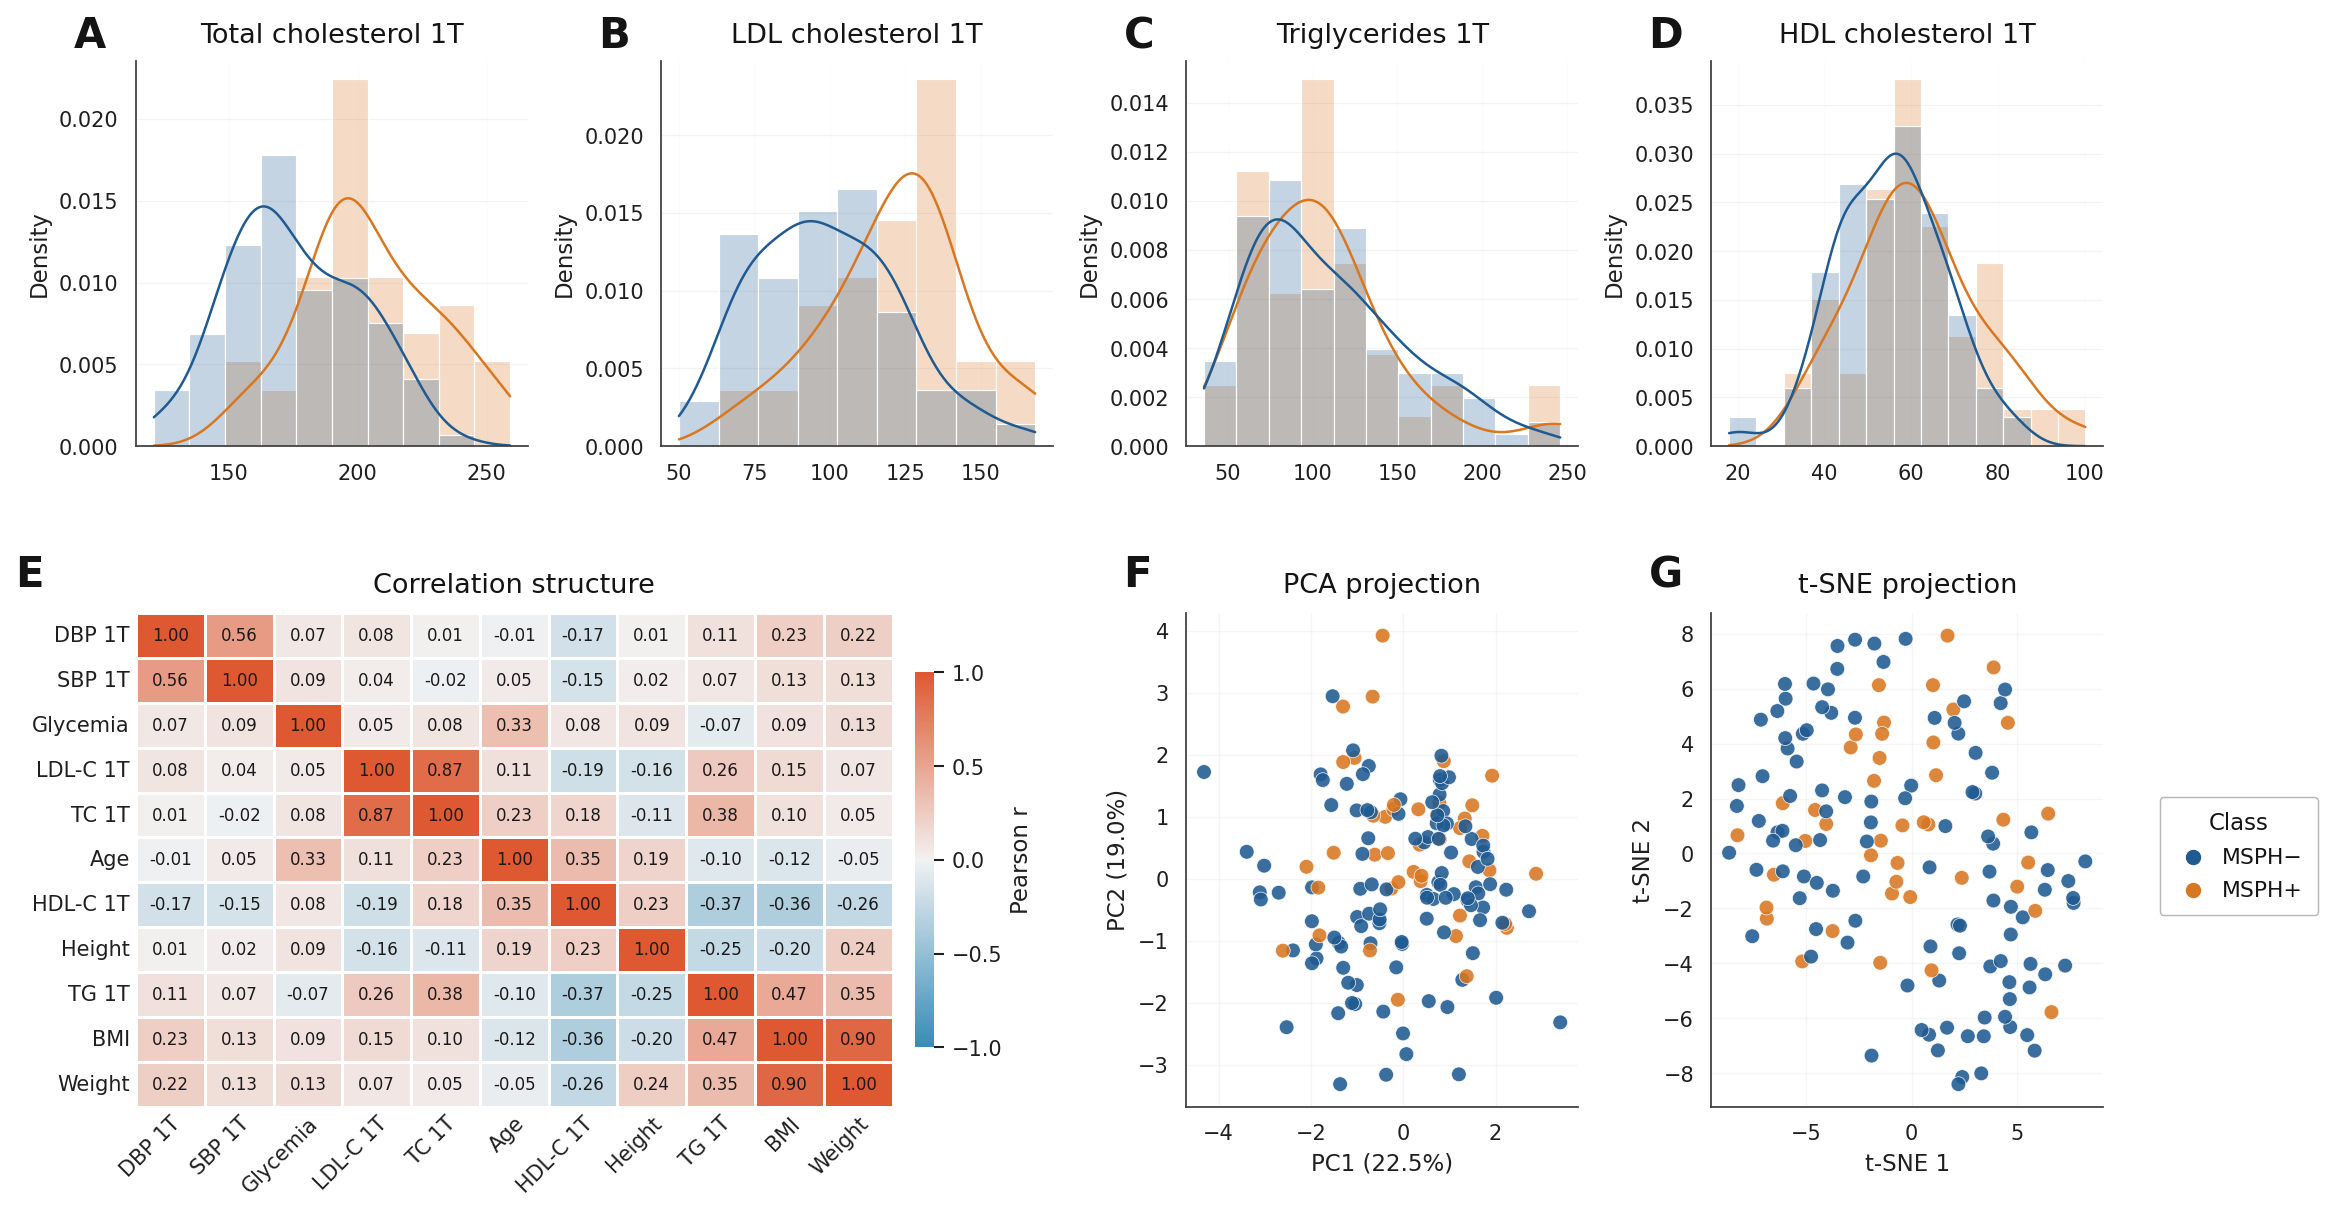

In [9]:
# ---------------------------------------------------------------------
# Manuscript-style plotting theme
# ---------------------------------------------------------------------
sns.set_theme(
    context="paper",
    style="white",
    font="DejaVu Sans",
    rc={
        "axes.linewidth": 0.85,
        "axes.edgecolor": "0.25",
        "axes.labelcolor": "0.12",
        "xtick.color": "0.12",
        "ytick.color": "0.12",
        "text.color": "0.08",
    },
)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

# Clean 2 x 4 manuscript grid:
# A-D occupy the first row.
# E is aligned with A and spans A+B in the second row.
# F and G occupy one full column each, aligned with C and D.
fig = plt.figure(figsize=(15.8, 8.35), constrained_layout=False)

gs = GridSpec(
    nrows=2,
    ncols=4,
    figure=fig,
    height_ratios=[1.0, 1.28],
    width_ratios=[1, 1, 1, 1],
    hspace=0.38,
    wspace=0.34,
)

panel_letters = ["A", "B", "C", "D", "E", "F", "G"]

# Top row: distribution panels
for i, feature in enumerate(distribution_features):
    ax = fig.add_subplot(gs[0, i])
    plot_distribution(ax, df_fig, feature, LABEL_COL)
    add_panel_label(ax, panel_letters[i])

# Bottom row: E spans columns A+B, F and G use full columns C and D.
ax_corr = fig.add_subplot(gs[1, 0:2])
plot_correlation(ax_corr, df_fig, corr_features, CORR_METHOD)
add_panel_label(ax_corr, "E")

ax_pca = fig.add_subplot(gs[1, 2])
plot_projection(
    ax_pca,
    Z_pca,
    y_proj,
    title="PCA projection",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)",
)
add_panel_label(ax_pca, "F")

ax_tsne = fig.add_subplot(gs[1, 3])
plot_projection(
    ax_tsne,
    Z_tsne,
    y_proj,
    title="t-SNE projection",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
)
add_panel_label(ax_tsne, "G")

# One shared class legend for panels A-D, F, and G.
add_shared_class_legend(fig)

if ADD_SUPTITLE:
    fig.suptitle(
        "Exploratory analysis of the early-pregnancy clinical feature space associated with MSPH",
        fontsize=15,
        fontweight="bold",
        y=0.985,
    )
    fig.subplots_adjust(left=0.055, right=0.885, top=0.915, bottom=0.13)
else:
    fig.subplots_adjust(left=0.055, right=0.885, top=0.965, bottom=0.13)

png_path = FIG_DIR / f"{FIGURE_BASENAME}.png"
pdf_path = FIG_DIR / f"{FIGURE_BASENAME}.pdf"
svg_path = FIG_DIR / f"{FIGURE_BASENAME}.svg"

if SAVE_PNG:
    fig.savefig(png_path, bbox_inches="tight")
    print("Saved:", png_path)
if SAVE_PDF:
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", pdf_path)
if SAVE_SVG:
    fig.savefig(svg_path, bbox_inches="tight")
    print("Saved:", svg_path)

plt.show()

## 8. Export figure metadata

This table records which dataset, features, and parameters were used to generate the panel. It is useful for reproducibility and figure captions.

In [10]:
metadata = pd.DataFrame([{
    "dataset_for_figure": DATASET_FOR_FIGURE,
    "label_col": LABEL_COL,
    "n_samples": df_fig.shape[0],
    "n_features_full": len(full_features),
    "n_features_pruned": len(pruned_features),
    "distribution_features": ";".join(distribution_features),
    "correlation_method": CORR_METHOD,
    "feature_set_for_corr": FEATURE_SET_FOR_CORR,
    "n_corr_features": len(corr_features),
    "feature_set_for_projection": FEATURE_SET_FOR_PROJECTION,
    "n_projection_features": len(projection_features_used),
    "pca_explained_variance_pc1": pca.explained_variance_ratio_[0],
    "pca_explained_variance_pc2": pca.explained_variance_ratio_[1],
    "tsne_perplexity": tsne_perplexity,
    "random_state": RANDOM_STATE,
}])

metadata_path = STATS_DIR / f"{FIGURE_BASENAME}_metadata.csv"
metadata.to_csv(metadata_path, index=False)
print("Saved:", metadata_path)
display(metadata)


Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/results/eda/stats/figure2_eda_panel_nature_style_metadata.csv


,dataset_for_figure,label_col,n_samples,n_features_full,n_features_pruned,distribution_features,correlation_method,feature_set_for_corr,n_corr_features,feature_set_for_projection,n_projection_features,pca_explained_variance_pc1,pca_explained_variance_pc2,tsne_perplexity,random_state
0,strict,MSPH,148,11,9,TC_1T;LDL_1T;TG_1T;HDL_1T,pearson,full,11,pruned,9,0.22513,0.19036,30,42


## 9. Optional caption draft

**Figure 2. Exploratory analysis of the early-pregnancy clinical feature space associated with maternal supraphysiological hypercholesterolemia.** Class-conditional distributions of representative first-trimester lipid variables show the strongest shifts for total cholesterol and LDL cholesterol, with weaker trends for triglycerides and greater overlap for HDL cholesterol. Correlation analysis reveals structured relationships among lipid, anthropometric, and hemodynamic predictors, indicating domain-specific redundancy alongside complementary clinical information. PCA and t-SNE projections show substantial overlap between MSPH-positive and MSPH-negative individuals, suggesting that the predictive signal is distributed across the clinical feature space rather than organized as clearly separable clusters.
